# BNCI2014_001 benchmark summary

This notebook is the final Stage 7 report for the BNCI2014_001 staged run. It reads only immutable experiment artifacts produced in Stages 4-6R and does not retrain models.

Primary claim level: leave-one-subject-out subject generalization over 5,184 MOABB motor-imagery epochs, four balanced classes, and nine held-out subjects.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 80)


## Source artifacts

The three benchmark families share the same BNCI task adapter and leave-one-subject-out evaluation protocol. The Torch full benchmark is exploratory and untuned; the classical CSP+LDA baseline remains the strongest result in this run.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "artifacts").exists() and (PROJECT_ROOT.parent / "artifacts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
ROOT = PROJECT_ROOT / "artifacts/experiments/bnci2014_001"
AUDIT_PATH = ROOT / "stage1_dataset_audit.json"
CSP_DIR = ROOT / "csp-lda" / "447f714497ed180e"
FEATURE_DIR = ROOT / "feature-logreg" / "902edd18de1c7e5b"
TORCH_DIR = ROOT / "torch-full" / "02d63e3c8ee8372d"
SUMMARY_PATH = ROOT / "stage7_benchmark_summary.json"

for path in [AUDIT_PATH, CSP_DIR / "evaluation.json", FEATURE_DIR / "evaluation.json", TORCH_DIR / "evaluation.json", TORCH_DIR / "comparison.json", TORCH_DIR / "manifest.json"]:
    if not path.exists():
        raise FileNotFoundError(path)

def load_json(path: Path) -> dict:
    with path.open(encoding="utf-8") as file:
        payload = json.load(file)
    if not isinstance(payload, dict):
        raise TypeError(f"Expected object JSON: {path}")
    return payload

audit = load_json(AUDIT_PATH)
csp_eval = load_json(CSP_DIR / "evaluation.json")
feature_eval = load_json(FEATURE_DIR / "evaluation.json")
torch_eval = load_json(TORCH_DIR / "evaluation.json")
torch_comparison = load_json(TORCH_DIR / "comparison.json")

def repo_relative(path: Path) -> str:
    return path.relative_to(PROJECT_ROOT).as_posix()

source_table = pd.DataFrame(
    [
        {"artifact": "Stage 1 audit", "path": repo_relative(AUDIT_PATH)},
        {"artifact": "CSP+LDA", "path": repo_relative(CSP_DIR)},
        {"artifact": "Project feature Logistic Regression", "path": repo_relative(FEATURE_DIR)},
        {"artifact": "Full Torch spectral benchmark", "path": repo_relative(TORCH_DIR)},
    ]
)
source_table


,artifact,path
0,Stage 1 audit,artifacts/experiments/bnci2014_001/stage1_data...
1,CSP+LDA,artifacts/experiments/bnci2014_001/csp-lda/447...
2,Project feature Logistic Regression,artifacts/experiments/bnci2014_001/feature-log...
3,Full Torch spectral benchmark,artifacts/experiments/bnci2014_001/torch-full/...


## Contract checks

These checks are deliberately small and strict: the report should fail if the class order, fold count, or sample count is inconsistent across artifacts.

In [3]:
EXPECTED_CLASSES = ["left_hand", "right_hand", "feet", "tongue"]
EXPECTED_N_FOLDS = 9
EXPECTED_N_SAMPLES = 5184

assert csp_eval["class_names"] == EXPECTED_CLASSES
assert feature_eval["class_names"] == EXPECTED_CLASSES
assert torch_eval["class_names"] == EXPECTED_CLASSES
assert csp_eval["summary"]["n_folds"] == EXPECTED_N_FOLDS
assert feature_eval["summary"]["n_folds"] == EXPECTED_N_FOLDS
assert all(variant["summary"]["n_folds"] == EXPECTED_N_FOLDS for variant in torch_eval["variants"])
assert csp_eval["summary"]["n_samples"] == EXPECTED_N_SAMPLES
assert feature_eval["summary"]["n_samples"] == EXPECTED_N_SAMPLES
assert all(variant["summary"]["n_samples"] == EXPECTED_N_SAMPLES for variant in torch_eval["variants"])

csp_folds = [fold["name"] for fold in csp_eval["folds"]]
feature_folds = [fold["name"] for fold in feature_eval["folds"]]
assert csp_folds == feature_folds
assert all([fold["name"] for fold in variant["folds"]] == csp_folds for variant in torch_eval["variants"])

contract = {
    "dataset": "BNCI2014_001",
    "subjects": audit["static_metadata"]["subject_list"],
    "classes": EXPECTED_CLASSES,
    "n_epochs": EXPECTED_N_SAMPLES,
    "n_folds": EXPECTED_N_FOLDS,
    "outer_protocol": "leave-one-subject-out",
    "stage_marker": "BNCI2014_001_BENCHMARK_VERIFIED",
}
contract


{'dataset': 'BNCI2014_001',
 'subjects': [1, 2, 3, 4, 5, 6, 7, 8, 9],
 'classes': ['left_hand', 'right_hand', 'feet', 'tongue'],
 'n_epochs': 5184,
 'n_folds': 9,
 'outer_protocol': 'leave-one-subject-out',
 'stage_marker': 'BNCI2014_001_BENCHMARK_VERIFIED'}

## Aggregate ranking

Balanced accuracy is the primary metric because the task is four-class classification and fold-level subject difficulty varies substantially.

In [4]:
def summary_row(model_id: str, family: str, architecture: str | None, method: str | None, summary: dict) -> dict:
    return {
        "model_id": model_id,
        "family": family,
        "architecture": architecture,
        "method": method,
        "balanced_accuracy_mean": summary["balanced_accuracy_mean"],
        "balanced_accuracy_std": summary["balanced_accuracy_std"],
        "macro_f1_mean": summary["macro_f1_mean"],
        "macro_f1_std": summary["macro_f1_std"],
        "n_folds": summary["n_folds"],
        "n_samples": summary["n_samples"],
    }

rows = [
    summary_row("csp-lda", "classical", None, "csp", csp_eval["summary"]),
    summary_row("feature-logreg", "project_features", None, "time+spectral", feature_eval["summary"]),
]
rows.extend(
    summary_row(
        variant["model_id"],
        "torch_full",
        variant["architecture"],
        variant["method"],
        variant["summary"],
    )
    for variant in torch_eval["variants"]
)

ranking = pd.DataFrame(rows).sort_values("balanced_accuracy_mean", ascending=False).reset_index(drop=True)
ranking["delta_vs_csp_lda"] = ranking["balanced_accuracy_mean"] - float(csp_eval["summary"]["balanced_accuracy_mean"])
ranking["delta_vs_feature_logreg"] = ranking["balanced_accuracy_mean"] - float(feature_eval["summary"]["balanced_accuracy_mean"])
ranking


,model_id,family,architecture,method,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,n_folds,n_samples,delta_vs_csp_lda,delta_vs_feature_logreg
0,csp-lda,classical,NaN,csp,0.385224,0.108631,0.334827,0.126102,9,5184,0.000000,0.034915
1,feature-logreg,project_features,NaN,time+spectral,0.350309,0.088304,0.312909,0.095944,9,5184,-0.034915,0.000000
2,deep-convnet-stft-bnci,torch_full,deep-convnet,stft,0.308063,0.053767,0.237155,0.079434,9,5184,-0.077160,-0.042245
3,deep-convnet-morlet-bnci,torch_full,deep-convnet,morlet,0.306134,0.064296,0.237556,0.095567,9,5184,-0.079090,-0.044174
4,deep-convnet-superlet-bnci,torch_full,deep-convnet,superlet,0.305363,0.058814,0.248068,0.075273,9,5184,-0.079861,-0.044946
5,eegnet-fft-bnci,torch_full,eegnet,fft,0.303434,0.047275,0.244621,0.057825,9,5184,-0.081790,-0.046875
6,eegnet-superlet-bnci,torch_full,eegnet,superlet,0.289352,0.038604,0.196731,0.052598,9,5184,-0.095872,-0.060957
7,shallow-convnet-superlet-bnci,torch_full,shallow-convnet,superlet,0.289159,0.048743,0.249137,0.068807,9,5184,-0.096065,-0.061150
8,eegnet-morlet-bnci,torch_full,eegnet,morlet,0.286844,0.043666,0.191070,0.061954,9,5184,-0.098380,-0.063465
9,shallow-convnet-stft-bnci,torch_full,shallow-convnet,stft,0.285880,0.038387,0.218983,0.067585,9,5184,-0.099344,-0.064429


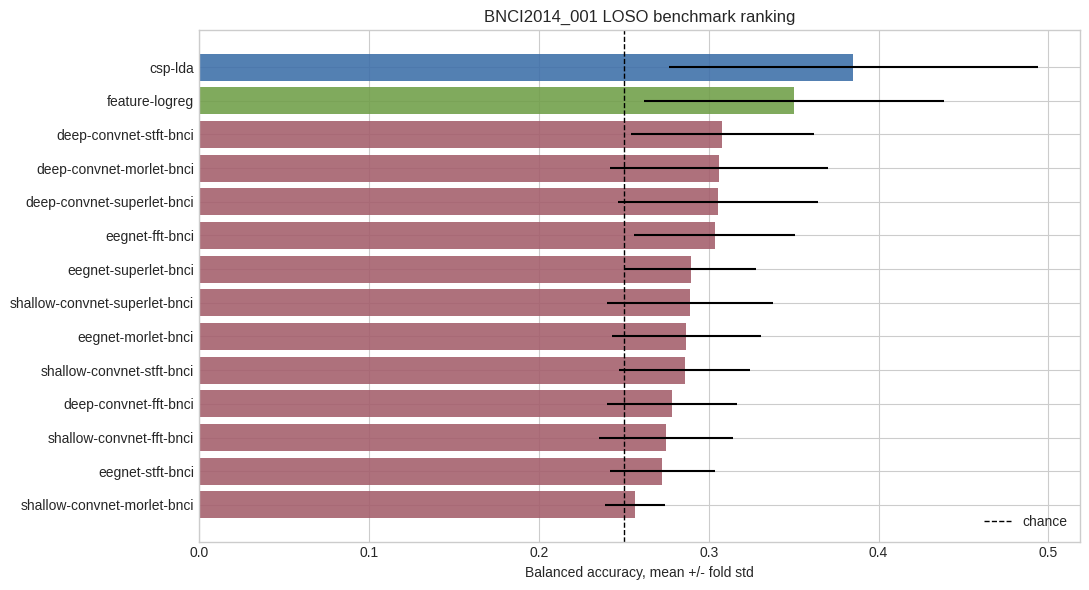

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
plot_df = ranking.sort_values("balanced_accuracy_mean", ascending=True)
colors = plot_df["family"].map({"classical": "#3b6ea8", "project_features": "#6f9e47", "torch_full": "#a35d6a"})
ax.barh(plot_df["model_id"], plot_df["balanced_accuracy_mean"], xerr=plot_df["balanced_accuracy_std"], color=colors, alpha=0.88)
ax.axvline(0.25, color="black", linestyle="--", linewidth=1, label="chance")
ax.set_xlabel("Balanced accuracy, mean +/- fold std")
ax.set_ylabel("")
ax.set_title("BNCI2014_001 LOSO benchmark ranking")
ax.legend(loc="lower right")
fig.tight_layout()


## Torch preprocessor and architecture view

The strongest neural variants are all `deep-convnet`, but the full Torch sweep remains below both classical references.

In [6]:
torch_df = ranking[ranking["family"] == "torch_full"].copy()
torch_pivot = torch_df.pivot(index="architecture", columns="method", values="balanced_accuracy_mean")
torch_pivot = torch_pivot[["fft", "morlet", "stft", "superlet"]]
torch_pivot


method,fft,morlet,stft,superlet
architecture,,,,
deep-convnet,0.278356,0.306134,0.308063,0.305363
eegnet,0.303434,0.286844,0.272762,0.289352
shallow-convnet,0.274884,0.256559,0.285880,0.289159


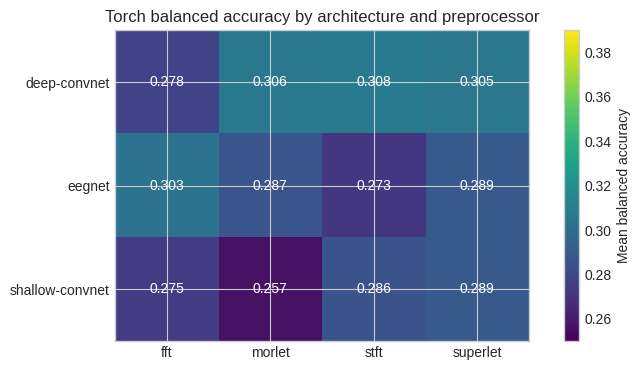

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
image = ax.imshow(torch_pivot.values, cmap="viridis", vmin=0.25, vmax=max(0.39, float(torch_pivot.max().max())))
ax.set_xticks(np.arange(torch_pivot.shape[1]), torch_pivot.columns)
ax.set_yticks(np.arange(torch_pivot.shape[0]), torch_pivot.index)
ax.set_title("Torch balanced accuracy by architecture and preprocessor")
for row_idx in range(torch_pivot.shape[0]):
    for col_idx in range(torch_pivot.shape[1]):
        value = torch_pivot.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f"{value:.3f}", ha="center", va="center", color="white" if value < 0.33 else "black")
fig.colorbar(image, ax=ax, label="Mean balanced accuracy")
fig.tight_layout()


## Held-out subject variability

Each fold holds out exactly one subject with 576 epochs. The fold spread is large enough that the mean alone should not be over-interpreted.

In [8]:
best_torch_id = ranking.loc[ranking["family"].eq("torch_full"), "model_id"].iloc[0]
best_torch = next(variant for variant in torch_eval["variants"] if variant["model_id"] == best_torch_id)

def fold_rows(model_id: str, folds: list[dict]) -> list[dict]:
    result = []
    for fold in folds:
        result.append(
            {
                "model_id": model_id,
                "subject": int(fold["test_subjects"][0]),
                "balanced_accuracy": fold["metrics"]["balanced_accuracy"],
                "macro_f1": fold["metrics"]["macro_f1"],
            }
        )
    return result

fold_df = pd.DataFrame(
    fold_rows("csp-lda", csp_eval["folds"])
    + fold_rows("feature-logreg", feature_eval["folds"])
    + fold_rows(best_torch_id, best_torch["folds"])
)
fold_df.pivot(index="subject", columns="model_id", values="balanced_accuracy")


model_id,csp-lda,deep-convnet-stft-bnci,feature-logreg
subject,,,
1,0.371528,0.336806,0.460069
2,0.276042,0.281250,0.258681
3,0.503472,0.331597,0.404514
4,0.392361,0.312500,0.333333
5,0.272569,0.239583,0.262153
6,0.230903,0.237847,0.279514
7,0.357639,0.355903,0.244792
8,0.539931,0.267361,0.435764
9,0.522569,0.409722,0.473958


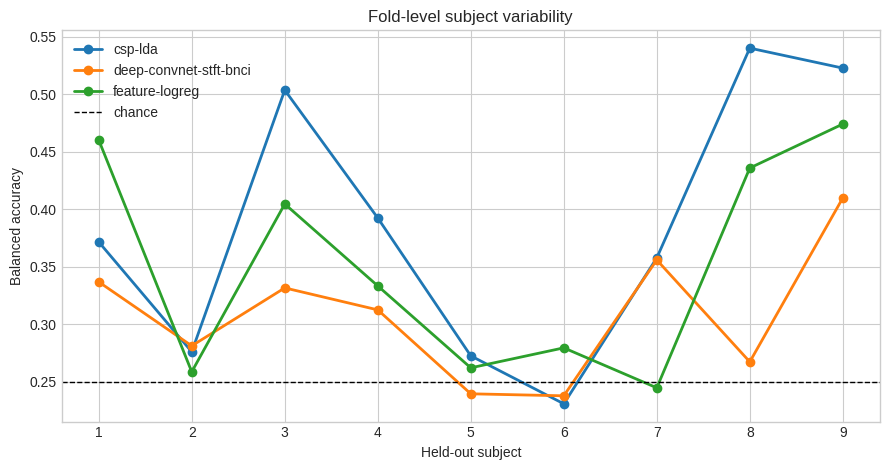

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for model_id, group in fold_df.groupby("model_id"):
    group = group.sort_values("subject")
    ax.plot(group["subject"], group["balanced_accuracy"], marker="o", linewidth=2, label=model_id)
ax.axhline(0.25, color="black", linestyle="--", linewidth=1, label="chance")
ax.set_xticks(sorted(fold_df["subject"].unique()))
ax.set_xlabel("Held-out subject")
ax.set_ylabel("Balanced accuracy")
ax.set_title("Fold-level subject variability")
ax.legend(loc="best")
fig.tight_layout()


## Aggregate confusion matrices

Matrices are row-normalized for readability. Rows are true labels; columns are predicted labels.

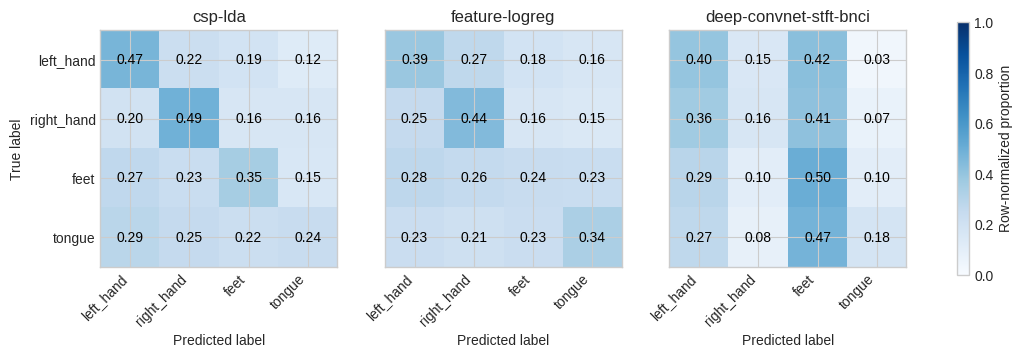

In [10]:
def row_normalized(matrix: list[list[int]]) -> np.ndarray:
    values = np.asarray(matrix, dtype=float)
    return values / values.sum(axis=1, keepdims=True)

confusions = {
    "csp-lda": csp_eval["summary"]["confusion_matrix"],
    "feature-logreg": feature_eval["summary"]["confusion_matrix"],
    best_torch_id: best_torch["summary"]["confusion_matrix"],
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for ax, (title, matrix) in zip(axes, confusions.items(), strict=True):
    normalized = row_normalized(matrix)
    image = ax.imshow(normalized, cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(EXPECTED_CLASSES)), EXPECTED_CLASSES, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(EXPECTED_CLASSES)), EXPECTED_CLASSES)
    for i in range(normalized.shape[0]):
        for j in range(normalized.shape[1]):
            value = normalized[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="white" if value > 0.55 else "black")
axes[0].set_ylabel("True label")
for ax in axes:
    ax.set_xlabel("Predicted label")
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.82, label="Row-normalized proportion")


## Stage 7 conclusion

The BNCI2014_001 adapter and benchmark pipeline are runnable end to end. CSP+LDA is the strongest reference in this staged run. The project feature baseline is lower but still ahead of the full untuned Torch sweep. The Torch result should be treated as an exploratory transfer check for previously studied backbones, not as a tuned neural motor-imagery system.

In [11]:
def json_clean(value):
    if isinstance(value, dict):
        return {key: json_clean(item) for key, item in value.items()}
    if isinstance(value, list):
        return [json_clean(item) for item in value]
    if isinstance(value, float) and np.isnan(value):
        return None
    return value

best_overall = json_clean(ranking.iloc[0].to_dict())
best_torch_row = json_clean(ranking[ranking["family"] == "torch_full"].iloc[0].to_dict())
stage7_summary = {
    "stage": "7 - Final Notebook, Report, And Memory Update",
    "marker": "BNCI2014_001_BENCHMARK_VERIFIED",
    "contract": contract,
    "best_overall": best_overall,
    "best_torch": best_torch_row,
    "csp_lda_balanced_accuracy_mean": float(csp_eval["summary"]["balanced_accuracy_mean"]),
    "feature_logreg_balanced_accuracy_mean": float(feature_eval["summary"]["balanced_accuracy_mean"]),
    "best_torch_delta_vs_csp_lda": float(best_torch_row["delta_vs_csp_lda"]),
    "best_torch_delta_vs_feature_logreg": float(best_torch_row["delta_vs_feature_logreg"]),
    "source_artifacts": source_table.to_dict(orient="records"),
    "ranking": json_clean(ranking.to_dict(orient="records")),
}
SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH.write_text(json.dumps(stage7_summary, allow_nan=False, indent=2, sort_keys=True) + "\n", encoding="utf-8")
print("BNCI2014_001_BENCHMARK_VERIFIED")
print(repo_relative(SUMMARY_PATH))


BNCI2014_001_BENCHMARK_VERIFIED
artifacts/experiments/bnci2014_001/stage7_benchmark_summary.json
